In [1]:
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)


monthly = df.groupby(['Year','Month','Category','Region']).agg(
    Total_Sales=('Sales','sum'),
    Total_Orders=('Order ID','count'),
    Avg_Discount=('Discount','mean'),
    Total_Profit=('Profit','sum')
).reset_index()

In [5]:
monthly = monthly.sort_values(['Category','Region','Year','Month']) 
monthly['lag_1'] = monthly.groupby(['Category','Region'])['Total_Sales'].shift(1) 
monthly['lag_2'] = monthly.groupby(['Category','Region'])['Total_Sales'].shift(2) 
monthly['lag_3'] = monthly.groupby(['Category','Region'])['Total_Sales'].shift(3) 

# Rolling average (3-month window)
monthly['rolling_avg_3'] = monthly.groupby( ['Category','Region'])['Total_Sales'].transform( lambda x: x.rolling(3, min_periods=1).mean())
# Encode categoricals 
le = LabelEncoder() 
monthly['Category_enc'] = le.fit_transform(monthly['Category']) 
monthly['Region_enc'] = le.fit_transform(monthly['Region'])
# Drop nulls created by lags 
monthly = monthly.dropna()

In [7]:
features = ['Year','Month','Category_enc','Region_enc',
             'lag_1','lag_2','lag_3','rolling_avg_3',
             'Total_Orders','Avg_Discount']

X = monthly[features]
y = monthly['Total_Sales']

# Time-based split (not random — critical for time series!)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model 1: Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 2: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Evaluation
for name, pred in [('Random Forest',rf_pred),('XGBoost',xgb_pred)]:
    print(f"\n{name}:")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.2f}")
    print(f"  MAE  : {mean_absolute_error(y_test, pred):.2f}")
    print(f"  R²   : {r2_score(y_test, pred):.4f}")


Random Forest:
  RMSE : 2917.93
  MAE  : 1657.60
  R²   : 0.5767

XGBoost:
  RMSE : 2789.08
  MAE  : 1548.11
  R²   : 0.6133



XGBoost:
  Avg MAE            : 1548.11
  Avg MAPE           : 77.36%
  Avg Model Accuracy : 64.67%

Random Forest:
  Avg MAE            : 1657.60
  Avg MAPE           : 86.66%
  Avg Model Accuracy : 62.49%


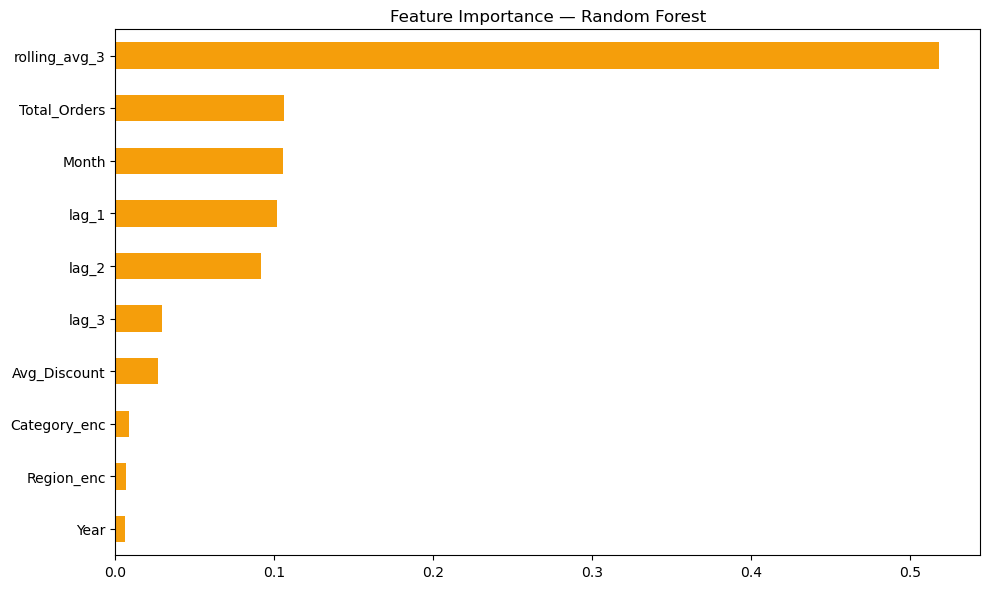


✅ Enriched predictions saved → data/predictions/sales_predictions.csv
   Columns: ['Date', 'Year', 'Month', 'Category_enc', 'Region_enc', 'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3', 'Total_Orders', 'Avg_Discount', 'Actual_Sales', 'RF_Predicted', 'XGB_Predicted', 'RF_MAE', 'RF_MAPE', 'RF_Accuracy_Pct', 'XGB_MAE', 'XGB_MAPE', 'XGB_Accuracy_Pct']


In [8]:
from sklearn.metrics import mean_absolute_error

# ── Helper: row-level MAPE (handle zero actuals safely) ──────────────────
def row_mape(actual, predicted):
    return np.where(
        actual == 0, np.nan,
        np.abs((actual - predicted) / actual) * 100
    )

# ── Build results DataFrame ───────────────────────────────────────────────
results = X_test.copy()
results['Actual_Sales']  = y_test.values
results['RF_Predicted']  = rf_pred
results['XGB_Predicted'] = xgb_pred

# ── NEW COLUMN 1: Date  (reconstruct from Year + Month columns) ───────────
results['Date'] = pd.to_datetime(
    results['Year'].astype(str) + '-' +
    results['Month'].astype(str).str.zfill(2) + '-01'
).dt.strftime('%Y-%m-%d')

# ── NEW COLUMN 2 & 3: Row-level MAE and MAPE for the best model (XGBoost) ─
# Row-level MAE = |Actual - Predicted| (absolute error per row)
results['XGB_MAE']  = np.abs(results['Actual_Sales'] - results['XGB_Predicted'])
results['RF_MAE']   = np.abs(results['Actual_Sales'] - results['RF_Predicted'])

# Row-level MAPE = |Actual - Predicted| / Actual × 100
results['XGB_MAPE'] = row_mape(results['Actual_Sales'].values,
                                  results['XGB_Predicted'].values)
results['RF_MAPE']  = row_mape(results['Actual_Sales'].values,
                                 results['RF_Predicted'].values)

# ── NEW COLUMN 4: Model Accuracy % = 100 - MAPE (capped at 0 minimum) ────
results['XGB_Accuracy_Pct'] = np.clip(100 - results['XGB_MAPE'], 0, 100)
results['RF_Accuracy_Pct']  = np.clip(100 - results['RF_MAPE'],  0, 100)

# ── Overall metrics (printed as summary) ─────────────────────────────────
for name, mae_col, mape_col, acc_col in [
    ('XGBoost',       'XGB_MAE',  'XGB_MAPE',  'XGB_Accuracy_Pct'),
    ('Random Forest', 'RF_MAE',   'RF_MAPE',   'RF_Accuracy_Pct'),
]:
    avg_mae  = results[mae_col].mean()
    avg_mape = results[mape_col].mean(skipna=True)
    avg_acc  = results[acc_col].mean(skipna=True)
    print(f"\n{name}:")
    print(f"  Avg MAE            : {avg_mae:.2f}")
    print(f"  Avg MAPE           : {avg_mape:.2f}%")
    print(f"  Avg Model Accuracy : {avg_acc:.2f}%")

# ── Reorder columns so the 4 new ones appear right after predictions ──────
col_order = [
    'Date', 'Year', 'Month', 'Category_enc', 'Region_enc',
    'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3',
    'Total_Orders', 'Avg_Discount',
    'Actual_Sales', 'RF_Predicted', 'XGB_Predicted',
    'RF_MAE',  'RF_MAPE',  'RF_Accuracy_Pct',
    'XGB_MAE', 'XGB_MAPE', 'XGB_Accuracy_Pct'
]
results = results[col_order]

# ── Save enriched CSV ─────────────────────────────────────────────────────
results.to_csv('../data/predictions/sales_predictions.csv', index=False)

# ── Feature Importance Chart ──────────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', figsize=(10,6), color='#f59e0b')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

print("\n✅ Enriched predictions saved → data/predictions/sales_predictions.csv")
print(f"   Columns: {list(results.columns)}")